# EfficientDet 실습
*EfficientDet hands-on*

## 1. 라이브러리 설치 및 환경 설정
*1. Install libraries and set up the environment*

In [1]:
!git clone https://github.com/zylo117/Yet-Another-EfficientDet-Pytorch.git
# !pip install opencv-python matplotlib pycocotools

Cloning into 'Yet-Another-EfficientDet-Pytorch'...
remote: Enumerating objects: 765, done.
remote: Total 765 (delta 0), reused 0 (delta 0), pack-reused 765 (from 1)
Receiving objects: 100% (765/765), 8.86 MiB | 20.76 MiB/s, done.
Resolving deltas: 100% (429/429), done.


In [2]:
import os

os.chdir('Yet-Another-EfficientDet-Pytorch')
print("현재 디렉토리:", os.getcwd())

현재 디렉토리: /content/Yet-Another-EfficientDet-Pytorch


In [3]:
!mkdir -p weights
!wget https://github.com/zylo117/Yet-Another-EfficientDet-Pytorch/releases/download/1.0/efficientdet-d0.pth -O weights/efficientdet-d0.pth

--2026-09-28 04:31:42--  https://github.com/zylo117/Yet-Another-EfficientDet-Pytorch/releases/download/1.0/efficientdet-d0.pth
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/253385242/9b9d2100-791d-11ea-80b2-d35899cf95fe?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-09-28T05%3A09%3A32Z&rscd=attachment%3B+filename%3Defficientdet-d0.pth&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-09-28T04%3A09%3A22Z&ske=2026-09-28T05%3A09%3A32Z&sks=b&skv=2018-11-09&sig=7%2FvVMOX6cq9mmaMDY6DuvyJlsXZ%2BnNFPUedg4CSaKGA%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc5MDU3MTcwMiwibmJmIjoxNzkwNTY5OTAyLCJwYXRoIjoicmVs

In [4]:
import torch
from backbone import EfficientDetBackbone
compound_coef = 0
model = EfficientDetBackbone(compound_coef=0, num_classes=90)

In [5]:
model.load_state_dict(torch.load(f'weights/efficientdet-d0.pth', map_location='cpu'))
model.requires_grad_(False)
model.eval()

EfficientDetBackbone(
  (bifpn): Sequential(
    (0): BiFPN(
      (conv6_up): SeparableConvBlock(
        (depthwise_conv): Conv2dStaticSamePadding(
          (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), groups=64, bias=False)
        )
        (pointwise_conv): Conv2dStaticSamePadding(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
        )
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
      (conv5_up): SeparableConvBlock(
        (depthwise_conv): Conv2dStaticSamePadding(
          (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), groups=64, bias=False)
        )
        (pointwise_conv): Conv2dStaticSamePadding(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
        )
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
      (conv4_up): SeparableConvBlock(
        (depthwise_conv): Conv2dStaticSamePadding(
      

In [6]:
compound_coef = 0
force_input_size = None  # set None to use default size
# img_path = 'bus.jpg'

anchor_ratios = [(1.0, 1.0), (1.4, 0.7), (0.7, 1.4)]
anchor_scales = [2 ** 0, 2 ** (1.0 / 3.0), 2 ** (2.0 / 3.0)]

threshold = 0.2
iou_threshold = 0.5

use_cuda = True
use_float16 = False


In [7]:
obj_list = ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light',
            'fire hydrant', '', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep',
            'cow', 'elephant', 'bear', 'zebra', 'giraffe', '', 'backpack', 'umbrella', '', '', 'handbag', 'tie',
            'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
            'skateboard', 'surfboard', 'tennis racket', 'bottle', '', 'wine glass', 'cup', 'fork', 'knife', 'spoon',
            'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut',
            'cake', 'chair', 'couch', 'potted plant', 'bed', '', 'dining table', '', '', 'toilet', '', 'tv',
            'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink',
            'refrigerator', '', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
            'toothbrush']

In [8]:
len(obj_list)

90

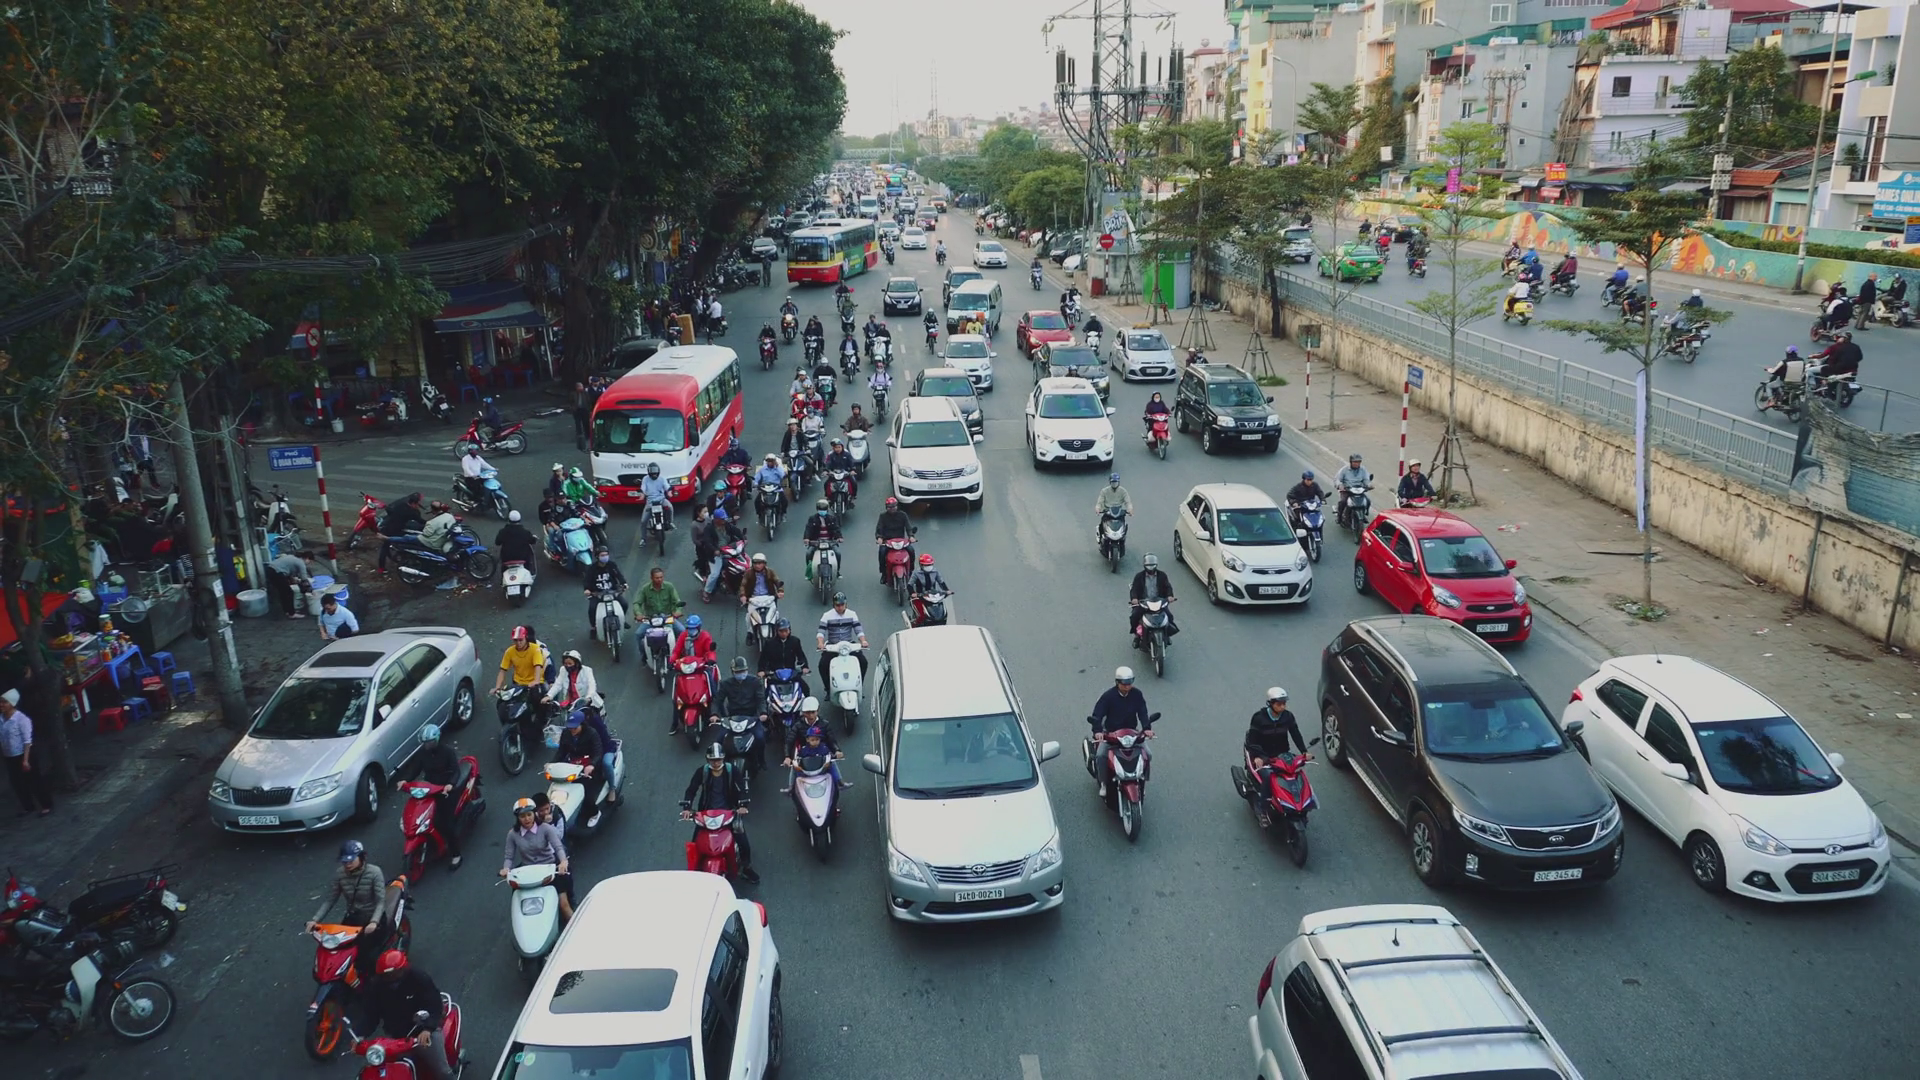

In [9]:
from PIL import Image
Image.open('test/img.png')

In [10]:
from utils.utils import preprocess, invert_affine, postprocess, STANDARD_COLORS, standard_to_bgr, get_index_label, plot_one_box

img_path = 'test/img.png'
color_list = standard_to_bgr(STANDARD_COLORS)
input_sizes = [512, 640, 768, 896, 1024, 1280, 1280, 1536, 1536]
input_size = input_sizes[compound_coef] if force_input_size is None else force_input_size
ori_imgs, framed_imgs, framed_metas = preprocess(img_path, max_size=input_size)
if use_cuda:
    x = torch.stack([torch.from_numpy(fi).cuda() for fi in framed_imgs], 0)
else:
    x = torch.stack([torch.from_numpy(fi) for fi in framed_imgs], 0)
x = x.to(torch.float32 if not use_float16 else torch.float16).permute(0, 3, 1, 2)

In [11]:
ori_imgs[0].shape, framed_imgs[0].shape

((1080, 1920, 3), (512, 512, 3))

In [12]:
framed_metas

[(512, 288, 1920, 1080, 0, 224)]

In [13]:
if use_cuda:
    model = model.cuda()
if use_float16:
    model = model.half()
with torch.no_grad():
    features, regression, classification, anchors = model(x)

In [14]:
features[0].shape, regression[0].shape, classification.shape, anchors.shape

(torch.Size([1, 64, 64, 64]),
 torch.Size([49104, 4]),
 torch.Size([1, 49104, 90]),
 torch.Size([1, 49104, 4]))

In [15]:
len(features)

5

In [16]:
features[0].shape, features[1].shape, features[2].shape, features[3].shape, features[4].shape

(torch.Size([1, 64, 64, 64]),
 torch.Size([1, 64, 32, 32]),
 torch.Size([1, 64, 16, 16]),
 torch.Size([1, 64, 8, 8]),
 torch.Size([1, 64, 4, 4]))

In [17]:
from utils.utils import postprocess
from efficientdet.utils import BBoxTransform, ClipBoxes

with torch.no_grad():
    features, regression, classification, anchors = model(x)
    regressBoxes = BBoxTransform() # 모델이 예측한 regression 값을 실제 bounding box 좌표로 변환
    clipBoxes = ClipBoxes()        # 모델이 예측한 object의 box가 이미지 범위를 벗어나지 않도록 조정
    out = postprocess(x,
                      anchors, regression, classification,
                      regressBoxes, clipBoxes,
                      threshold, iou_threshold)


In [18]:
out

[{'rois': array([[333.90854   , 239.91882   , 424.3854    , 287.47577   ],
         [314.5766    , 129.69444   , 351.32953   , 163.35027   ],
         [350.1861    , 165.45123   , 433.3695    , 241.53812   ],
         [130.68173   , 232.13904   , 207.67441   , 287.58868   ],
         [362.0021    , 135.14642   , 408.66135   , 169.6908    ],
         [ 56.52711   , 167.49118   , 129.53185   , 224.72946   ],
         [414.87576   , 173.1823    , 506.79477   , 242.5576    ],
         [  0.8863888 , 233.43379   ,  48.700577  , 277.26804   ],
         [ 80.504974  , 246.79994   , 122.74979   , 286.69684   ],
         [232.99295   , 165.08078   , 285.2722    , 247.46469   ],
         [378.50674   , 169.7482    , 458.36264   , 240.48508   ],
         [155.38026   ,  93.80188   , 196.91176   , 136.37054   ],
         [330.41702   , 184.25446   , 351.00174   , 229.17694   ],
         [290.06638   , 180.93594   , 309.02835   , 222.59875   ],
         [236.92749   , 112.801186  , 263.35803   , 13

In [19]:
out[0]['rois'].shape, out[0]['class_ids'].shape, out[0]['scores'].shape

((44, 4), (44,), (44,))

In [20]:
import cv2
def display(preds, imgs, imshow=True, imwrite=False):
    for i in range(len(imgs)):
        if len(preds[i]['rois']) == 0:
            continue

        imgs[i] = imgs[i].copy()

        for j in range(len(preds[i]['rois'])):
            x1, y1, x2, y2 = preds[i]['rois'][j].astype(np.int32)
            obj = obj_list[preds[i]['class_ids'][j]]
            score = float(preds[i]['scores'][j])
            plot_one_box(imgs[i], [x1, y1, x2, y2], label=obj,score=score,color=color_list[get_index_label(obj, obj_list)])


        if imshow:
            cv2.imshow('img', imgs[i])
            cv2.waitKey(0)

        if imwrite:
            cv2.imwrite(f'test/img_inferred_d{compound_coef}_this_repo_{i}.jpg', imgs[i])

    return f'test/img_inferred_d{compound_coef}_this_repo_'



In [21]:
import numpy as np
out = invert_affine(framed_metas, out)
img_path = display(out, ori_imgs, imshow=False, imwrite=True)

In [22]:
img_path

'test/img_inferred_d0_this_repo_'

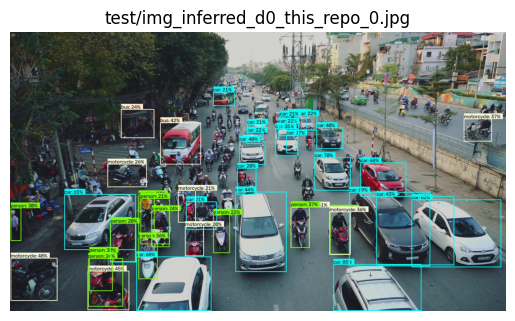

In [23]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = f"{img_path}0.jpg"  # 파일 확장자에 따라 수정 가능

img = Image.open(img_path)

# 이미지 출력
plt.imshow(img)
plt.axis('off')  # 축 제거
plt.title(img_path)
plt.show()

### 영상 분석
*Video inference*

In [24]:
!pwd

/content/Yet-Another-EfficientDet-Pytorch


In [27]:
import os
os.chdir('/content/Yet-Another-EfficientDet-Pytorch')   # make sure you're in the repo

from google.colab import files
uploaded = files.upload()
print(uploaded.keys())

Saving soccer.mp4 to soccer.mp4
dict_keys(['soccer.mp4'])


In [28]:
os.path.exists('soccer.mp4')

True

In [29]:
# Core Author: Zylo117
# Script's Author: winter2897

"""
Simple Inference Script of EfficientDet-Pytorch for detecting objects on webcam
"""
import time
import torch
import cv2
import numpy as np
from torch.backends import cudnn
from backbone import EfficientDetBackbone
from efficientdet.utils import BBoxTransform, ClipBoxes
from utils.utils import preprocess, invert_affine, postprocess, preprocess_video

# Video's path
video_src = 'soccer.mp4'  # set int to use webcam, set str to read from a video file
# output_dir = './output_soccer_frames'
output_dir = '/content/Yet-Another-EfficientDet-Pytorch/output_soccer_frames'
output_video_path = '/content/Yet-Another-EfficientDet-Pytorch/output_soccer.mp4'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

compound_coef = 0
force_input_size = 512  # set None to use default size

threshold = 0.2
iou_threshold = 0.2

use_cuda = True
use_float16 = False

obj_list = ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light',
            'fire hydrant', '', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep',
            'cow', 'elephant', 'bear', 'zebra', 'giraffe', '', 'backpack', 'umbrella', '', '', 'handbag', 'tie',
            'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
            'skateboard', 'surfboard', 'tennis racket', 'bottle', '', 'wine glass', 'cup', 'fork', 'knife', 'spoon',
            'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut',
            'cake', 'chair', 'couch', 'potted plant', 'bed', '', 'dining table', '', '', 'toilet', '', 'tv',
            'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink',
            'refrigerator', '', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
            'toothbrush']

input_sizes = [512, 640, 768, 896, 1024, 1280, 1280, 1536, 1536]
input_size = input_sizes[compound_coef] if force_input_size is None else force_input_size

# load model
model = EfficientDetBackbone(compound_coef=compound_coef, num_classes=len(obj_list))
model.load_state_dict(torch.load(f'weights/efficientdet-d{compound_coef}.pth'))
model.requires_grad_(False)
model.eval()

EfficientDetBackbone(
  (bifpn): Sequential(
    (0): BiFPN(
      (conv6_up): SeparableConvBlock(
        (depthwise_conv): Conv2dStaticSamePadding(
          (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), groups=64, bias=False)
        )
        (pointwise_conv): Conv2dStaticSamePadding(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
        )
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
      (conv5_up): SeparableConvBlock(
        (depthwise_conv): Conv2dStaticSamePadding(
          (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), groups=64, bias=False)
        )
        (pointwise_conv): Conv2dStaticSamePadding(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
        )
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
      (conv4_up): SeparableConvBlock(
        (depthwise_conv): Conv2dStaticSamePadding(
      

In [30]:
if use_cuda:
    model = model.cuda()
if use_float16:
    model = model.half()


In [31]:
# function for display
def display(preds, imgs):
    for i in range(len(imgs)):
        if len(preds[i]['rois']) == 0:
            return imgs[i]

        for j in range(len(preds[i]['rois'])):
            (x1, y1, x2, y2) = preds[i]['rois'][j].astype(np.int64)
            cv2.rectangle(imgs[i], (x1, y1), (x2, y2), (255, 255, 0), 2)
            obj = obj_list[preds[i]['class_ids'][j]]
            score = float(preds[i]['scores'][j])

            cv2.putText(imgs[i], '{}, {:.3f}'.format(obj, score),
                        (x1, y1 + 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                        (255, 255, 0), 1)

        return imgs[i]
# Box
regressBoxes = BBoxTransform()
clipBoxes = ClipBoxes()


In [32]:
# Video capture
cap = cv2.VideoCapture(video_src)
print("video opened:", cap.isOpened(), "| total frames:", int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
if not cap.isOpened():
    raise RuntimeError(f"Can't read {video_src} — check that it's uploaded to {os.getcwd()}")

frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # frame preprocessing
    ori_imgs, framed_imgs, framed_metas = preprocess_video(frame, max_size=input_size)

    if use_cuda:
        x = torch.stack([torch.from_numpy(fi).cuda() for fi in framed_imgs], 0)
    else:
        x = torch.stack([torch.from_numpy(fi) for fi in framed_imgs], 0)

    x = x.to(torch.float32 if not use_float16 else torch.float16).permute(0, 3, 1, 2)

    # model predict
    with torch.no_grad():
        features, regression, classification, anchors = model(x)
        out = postprocess(x, anchors, regression, classification,
                          regressBoxes, clipBoxes, threshold, iou_threshold)

    # result (display called once — the original drew every box twice)
    out = invert_affine(framed_metas, out)
    img_show = display(out, ori_imgs)

    # 프레임 저장 (save frame)
    frame_path = os.path.join(output_dir, f'frame_{frame_idx:05d}.jpg')
    if not cv2.imwrite(frame_path, img_show):
        raise RuntimeError(f"Failed to save {frame_path}")
    frame_idx += 1

    if frame_idx % 20 == 0:
        print("processed", frame_idx, "frames")

cap.release()
print("done — saved", frame_idx, "frames to", output_dir)

video opened: True | total frames: 876
processed 20 frames
processed 40 frames
processed 60 frames
processed 80 frames
processed 100 frames
processed 120 frames
processed 140 frames
processed 160 frames
processed 180 frames
processed 200 frames
processed 220 frames
processed 240 frames
processed 260 frames
processed 280 frames
processed 300 frames
processed 320 frames
processed 340 frames
processed 360 frames
processed 380 frames
processed 400 frames
processed 420 frames
processed 440 frames
processed 460 frames
processed 480 frames
processed 500 frames
processed 520 frames
processed 540 frames
processed 560 frames
processed 580 frames
processed 600 frames
processed 620 frames
processed 640 frames
processed 660 frames
processed 680 frames
processed 700 frames
processed 720 frames
processed 740 frames
processed 760 frames
processed 780 frames
processed 800 frames
processed 820 frames
processed 840 frames
processed 860 frames
done — saved 876 frames to /content/Yet-Another-EfficientDet-P

In [33]:
!ls -l

total 30124
-rw-r--r-- 1 root root     3672 Sep 28 04:31 backbone.py
drwxr-xr-x 2 root root     4096 Sep 28 04:31 benchmark
-rw-r--r-- 1 root root     5465 Sep 28 04:31 coco_eval.py
drwxr-xr-x 3 root root     4096 Sep 28 04:32 efficientdet
-rw-r--r-- 1 root root     5013 Sep 28 04:31 efficientdet_test.py
-rw-r--r-- 1 root root     4027 Sep 28 04:31 efficientdet_test_videos.py
drwxr-xr-x 3 root root     4096 Sep 28 04:32 efficientnet
-rw-r--r-- 1 root root     7652 Sep 28 04:31 LICENSE
drwxr-xr-x 2 root root    36864 Sep 28 04:49 output_soccer_frames
drwxr-xr-x 2 root root     4096 Sep 28 04:31 projects
drwxr-xr-x 2 root root     4096 Sep 28 04:32 __pycache__
-rw-r--r-- 1 root root    16644 Sep 28 04:31 readme.md
drwxr-xr-x 2 root root     4096 Sep 28 04:31 res
-rw-r--r-- 1 root root 30698938 Sep 28 04:44 soccer.mp4
drwxr-xr-x 2 root root     4096 Sep 28 04:31 test
-rw-r--r-- 1 root root    14442 Sep 28 04:31 train.py
drwxr-xr-x 2 root root     4096 Sep 28 04:31 tutorial
drwxr-xr-x 4 ro

In [34]:
os.listdir(output_dir)[:10]

['frame_00417.jpg',
 'frame_00204.jpg',
 'frame_00051.jpg',
 'frame_00078.jpg',
 'frame_00815.jpg',
 'frame_00697.jpg',
 'frame_00685.jpg',
 'frame_00397.jpg',
 'frame_00771.jpg',
 'frame_00477.jpg']

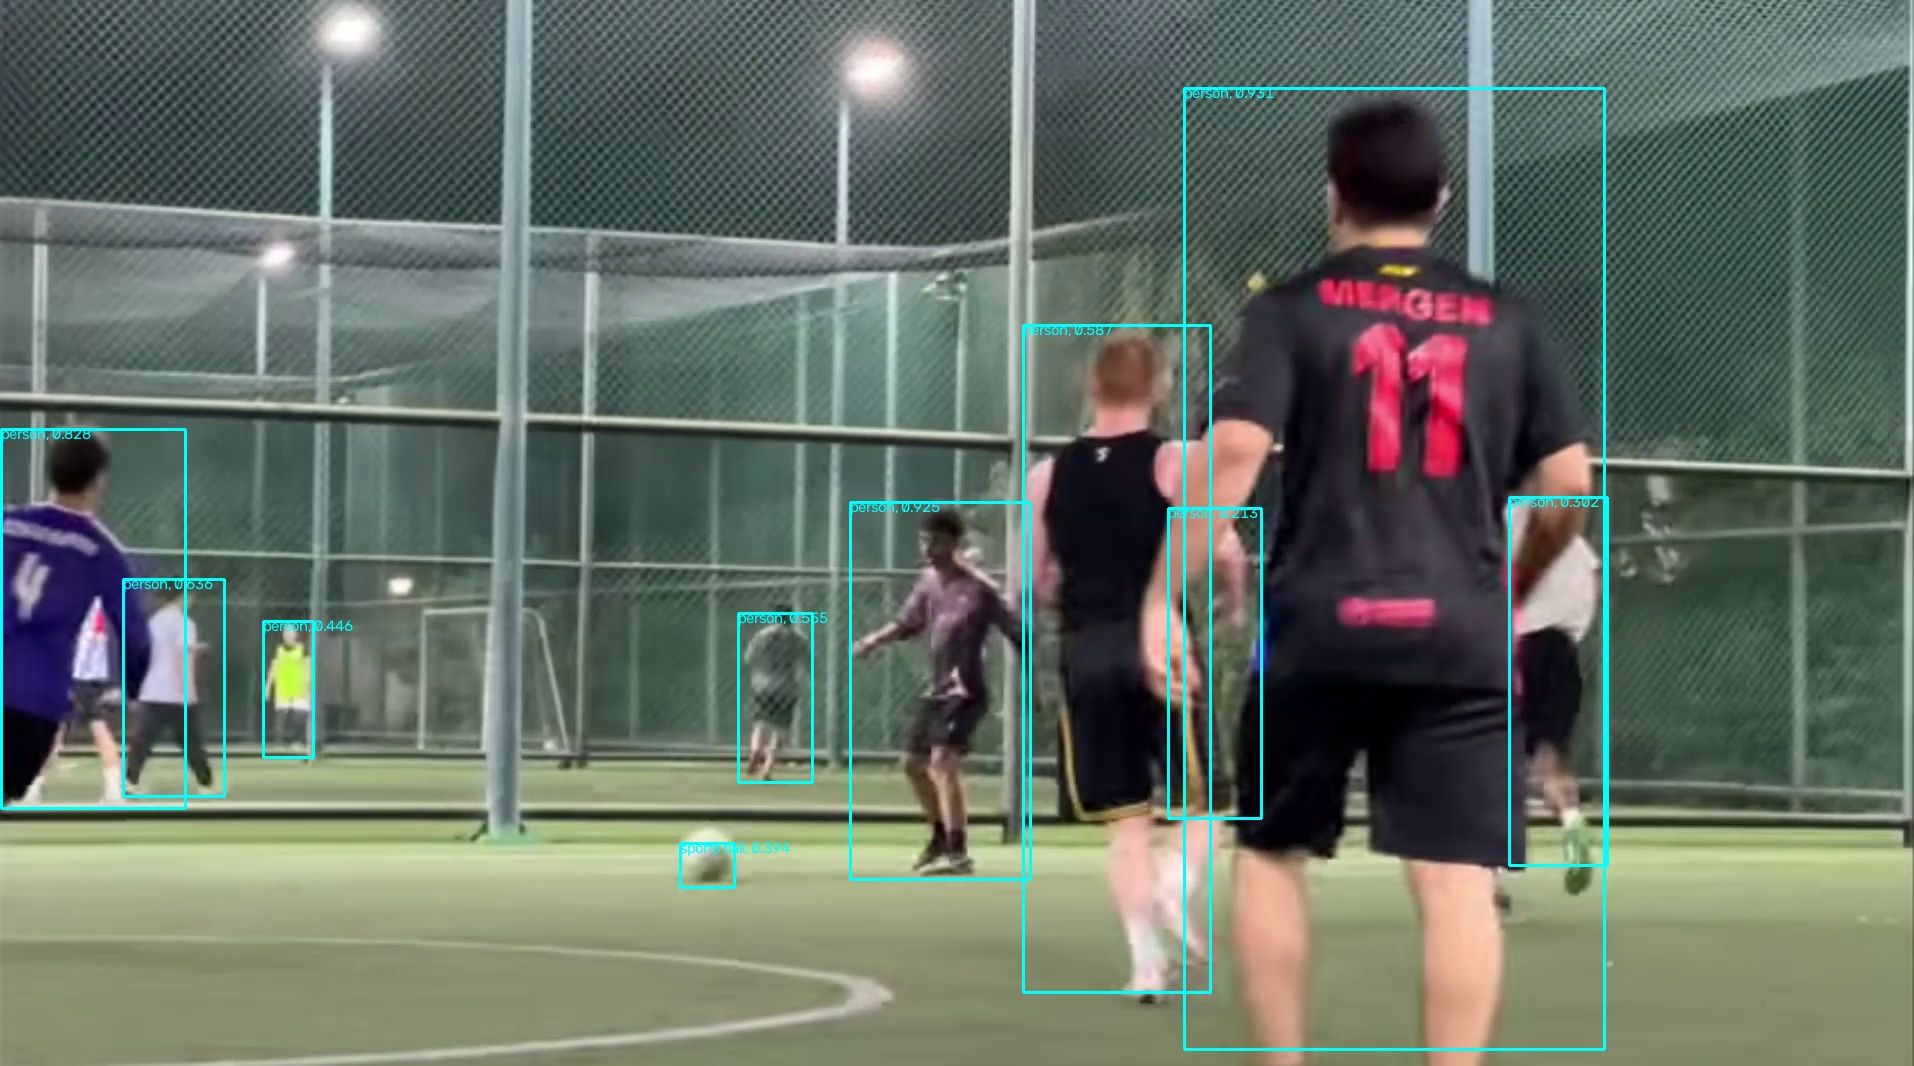

In [36]:
img = Image.open(os.path.join(output_dir, 'frame_00444.jpg'))
img

In [37]:
# 🔄 이미지들을 비디오로 합치기
images = sorted([img for img in os.listdir(output_dir) if img.endswith(".jpg")])
first_frame = cv2.imread(os.path.join(output_dir, images[0]))
height, width, _ = first_frame.shape

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out_video = cv2.VideoWriter(output_video_path, fourcc, 20.0, (width, height))  # 20fps

for image_file in images:
    img = cv2.imread(os.path.join(output_dir, image_file))
    out_video.write(img)

out_video.release()
print(f"✅ 영상 생성 완료: {output_video_path}")

✅ 영상 생성 완료: /content/Yet-Another-EfficientDet-Pytorch/output_soccer.mp4


In [38]:
os.path.exists(output_video_path)

True

### 학습
*Training*

## Custom dataset 학습 (Car video)
*Training on a custom dataset (car video)*

https://www.kaggle.com/datasets/pkdarabi/vehicle-detection-image-dataset

### 1. 데이터셋 준비
*1. Prepare the dataset*

다운로드한 Kaggle 데이터셋의 원본 구조
*Structure of the downloaded Kaggle dataset*

- Yet-Another-EfficientDet-Pytorch
    - datasets
        - car_detect
            - Apply_Grayscale
                - Apply_Grayscale
                    - Vehicles_Detection.v9i.coco
                        - test
                            - _annotations.coco.json
                            - XXXX.jpg
                        - train
                        - valid

이 repo의 학습 스크립트가 요구하는 구조로 변환해야 한다
*Target layout required by this repo's training script*

- Yet-Another-EfficientDet-Pytorch
    - projects
        - my_car_detect_proj.yml
    - datasets
        - car_detect
        - my_car_detect_proj
            - annotations
                - instances_train.json
                - instances_valid.json
                - instances_test.json
            - train
                - XXX.jpg
                - XXX.jpg
            - valid
                - XXX.jpg
                - XXX.jpg
            - test
                - XXX.jpg
                - XXX.jpg

In [40]:
import os, getpass
os.environ['KAGGLE_USERNAME'] = input('Kaggle username: ').strip()
os.environ['KAGGLE_KEY'] = getpass.getpass('Kaggle API key: ').strip()

Kaggle username: Jeminana
Kaggle API key: ··········


In [54]:
!pip install -q kaggle
!mkdir -p datasets
!kaggle datasets download -d pkdarabi/vehicle-detection-image-dataset -p ./datasets
!ls -lh datasets/

Dataset URL: https://www.kaggle.com/datasets/pkdarabi/vehicle-detection-image-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
vehicle-detection-image-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
total 263M
drwxr-xr-x 4 root root 4.0K Sep 28 05:00 car_detect
-rw-r--r-- 1 root root 263M Apr  9  2024 vehicle-detection-image-dataset.zip


In [56]:
!unzip -qo ./datasets/vehicle-detection-image-dataset.zip -d ./datasets/car_detect
!ls datasets/car_detect

Apply_Grayscale     Sample_Video_HighQuality.mp4
No_Apply_Grayscale  SampleVideo_LowQuality.mp4


In [57]:
!ls datasets/car_detect/No_Apply_Grayscale/No_Apply_Grayscale/
!ls datasets/car_detect/Apply_Grayscale/Apply_Grayscale/
!ls datasets/car_detect/No_Apply_Grayscale/No_Apply_Grayscale/Vehicles_Detection.v8i.coco/
!ls datasets/car_detect/No_Apply_Grayscale/No_Apply_Grayscale/Vehicles_Detection.v8i.coco/train | head -5

Vehicles_Detection.v8i.coco	   Vehicles_Detection.v8i.yolov8
Vehicles_Detection.v8i.tensorflow  Vehicles_Detection.v8i.yolov9
Vehicles_Detection.v9i.coco	   Vehicles_Detection.v9i.yolov8
Vehicles_Detection.v9i.tensorflow  Vehicles_Detection.v9i.yolov9
test  train  valid
_annotations.coco.json
frame_0002_jpg.rf.a929cd43bfa0953ace4ea9ea00fa9ba7.jpg
frame_0087_jpg.rf.6911e25ecb00139750616b606571e714.jpg
frame_0182_jpg.rf.24ccc1dc2e78b06ec38094471560e981.jpg
frame_0435_jpg.rf.b64a627a937f4b21417074ddc983c184.jpg


### 2. yml 파일 준비
*2. Prepare the project yml file*

 - projects
     - my_car_detect_proj.yml

In [58]:
import os
import json
import cv2
import matplotlib.pyplot as plt

def show_single_coco_image(
    coco_json_path,
    image_dir,
    image_index=0  # 시각화할 이미지 순서 (0부터 시작)
):
    # Load annotation JSON
    with open(coco_json_path, 'r') as f:
        coco = json.load(f)

    # Map image_id to image metadata
    image_info = coco['images'][image_index]
    image_id = image_info['id']
    file_name = image_info['file_name']
    img_path = os.path.join(image_dir, file_name)

    # Load image
    img = cv2.imread(img_path)
    if img is None:
        print(f"이미지를 불러올 수 없습니다: {img_path}")
        return

    # Index annotations for this image
    anns = [ann for ann in coco['annotations'] if ann['image_id'] == image_id]
    cat_id_to_name = {cat['id']: cat['name'] for cat in coco['categories']}

    # Draw bounding boxes
    for ann in anns:
        x, y, w, h = map(int, ann['bbox'])
        category_id = ann['category_id']
        label = cat_id_to_name.get(category_id, str(category_id))

        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(img, label, (x, y - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

    # Convert BGR to RGB for matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Show image
    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.title(file_name)
    plt.axis('off')
    plt.show()


In [49]:
!ls -l

total 90196
-rw-r--r-- 1 root root     3672 Sep 28 04:31 backbone.py
drwxr-xr-x 2 root root     4096 Sep 28 04:31 benchmark
-rw-r--r-- 1 root root     5465 Sep 28 04:31 coco_eval.py
drwxr-xr-x 3 root root     4096 Sep 28 05:00 datasets
drwxr-xr-x 3 root root     4096 Sep 28 04:32 efficientdet
-rw-r--r-- 1 root root     5013 Sep 28 04:31 efficientdet_test.py
-rw-r--r-- 1 root root     4027 Sep 28 04:31 efficientdet_test_videos.py
drwxr-xr-x 3 root root     4096 Sep 28 04:32 efficientnet
-rw-r--r-- 1 root root     7652 Sep 28 04:31 LICENSE
drwxr-xr-x 2 root root    36864 Sep 28 04:49 output_soccer_frames
-rw-r--r-- 1 root root 61508612 Sep 28 04:50 output_soccer.mp4
drwxr-xr-x 2 root root     4096 Sep 28 04:31 projects
drwxr-xr-x 2 root root     4096 Sep 28 04:32 __pycache__
-rw-r--r-- 1 root root    16644 Sep 28 04:31 readme.md
drwxr-xr-x 2 root root     4096 Sep 28 04:31 res
-rw-r--r-- 1 root root 30698938 Sep 28 04:44 soccer.mp4
drwxr-xr-x 2 root root     4096 Sep 28 04:31 test
-rw-r-

In [50]:
!pwd

/content/Yet-Another-EfficientDet-Pytorch


In [59]:
SRC = 'datasets/car_detect/No_Apply_Grayscale/No_Apply_Grayscale/Vehicles_Detection.v8i.coco'

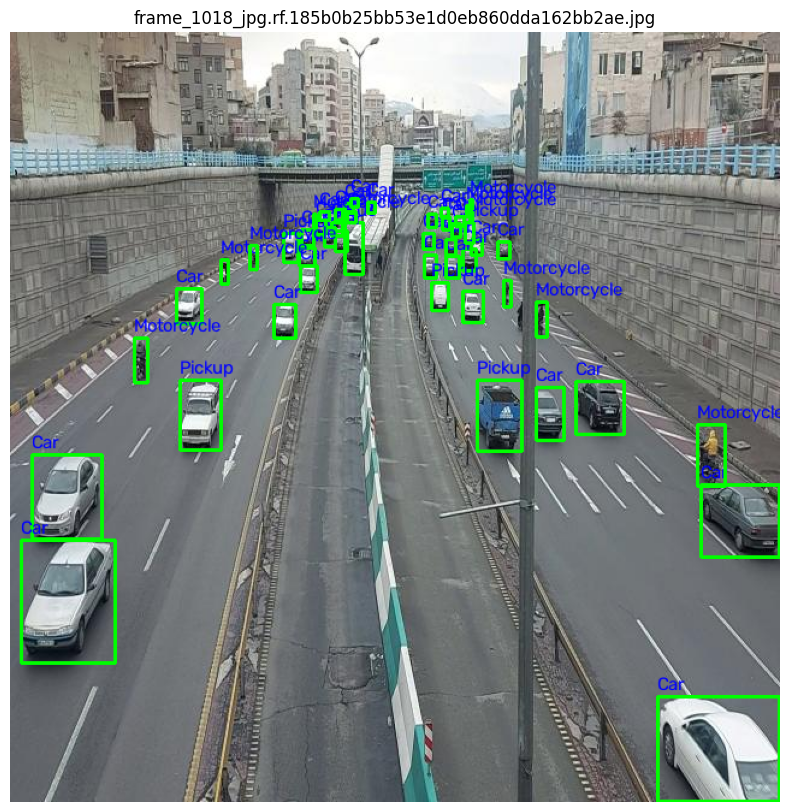

In [61]:
show_single_coco_image(
    coco_json_path=f'{SRC}/test/_annotations.coco.json',
    image_dir=f'{SRC}/test',
    image_index=2
)


### mean, std, anchor 계산
*Compute dataset mean / std and anchor statistics*

In [62]:
import os
import cv2
import numpy as np
from glob import glob
from tqdm import tqdm

def compute_mean_std(image_dir, max_images=None):
    image_paths = sorted(glob(os.path.join(image_dir, '*.jpg')))
    if max_images:
        image_paths = image_paths[:max_images]

    means = []
    stds = []

    for path in tqdm(image_paths, desc="Computing mean/std"):
        img = cv2.imread(path)  # BGR
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = img / 255.0
        means.append(np.mean(img, axis=(0, 1)))
        stds.append(np.std(img, axis=(0, 1)))

    mean = np.mean(means, axis=0)
    std = np.mean(stds, axis=0)

    print(f"✅ RGB mean: {mean.tolist()}")
    print(f"✅ RGB std : {std.tolist()}")
    return mean.tolist(), std.tolist()

In [63]:
compute_mean_std(f'{SRC}/train')

Computing mean/std: 100%|██████████| 102/102 [00:03<00:00, 33.86it/s]

✅ RGB mean: [0.4639068720376132, 0.4723598790503507, 0.4700067273366889]
✅ RGB std : [0.16533415666407805, 0.16423948194385204, 0.16310458962308103]


([0.4639068720376132, 0.4723598790503507, 0.4700067273366889],
 [0.16533415666407805, 0.16423948194385204, 0.16310458962308103])

In [64]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def analyze_bbox_ratios_and_scales(coco_json_path, show_plots=True):

    with open(coco_json_path, 'r') as f:
        coco = json.load(f)

    # 바운딩 박스 정보 추출
    widths, heights, areas = [], [], []
    category_stats = defaultdict(list)  # 카테고리별 통계

    # 카테고리 이름 매핑
    cat_id_to_name = {cat['id']: cat['name'] for cat in coco['categories']}

    for ann in coco['annotations']:
        x, y, w, h = ann['bbox']
        if w > 0 and h > 0:  # 유효한 바운딩 박스만
            widths.append(w)
            heights.append(h)
            areas.append(w * h)

            # 카테고리별 분석을 위해
            cat_name = cat_id_to_name.get(ann['category_id'], 'unknown')
            category_stats[cat_name].append((w, h))

    widths = np.array(widths)
    heights = np.array(heights)
    areas = np.array(areas)

    # 1. Aspect Ratios 계산
    ratios = widths / heights

    # 2. Scales 계산 (면적의 제곱근)
    scales = np.sqrt(areas)

    # 3. 시각화
    if show_plots:
        plt.figure(figsize=(15, 5))

        # Aspect Ratios 히스토그램
        plt.subplot(1, 3, 1)
        plt.hist(ratios, bins=50, alpha=0.7, edgecolor='black')
        plt.axvline(np.median(ratios), color='red', linestyle='--',
                   label=f'Median: {np.median(ratios):.2f}')
        plt.xlabel('Aspect Ratio (W/H)')
        plt.ylabel('Frequency')
        plt.title('Distribution of Aspect Ratios')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Scales 히스토그램
        plt.subplot(1, 3, 2)
        plt.hist(scales, bins=50, alpha=0.7, edgecolor='black')
        plt.axvline(np.median(scales), color='red', linestyle='--',
                   label=f'Median: {np.median(scales):.1f}')
        plt.xlabel('Scale (sqrt of area)')
        plt.ylabel('Frequency')
        plt.title('Distribution of Scales')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Log scale로 스케일 분포 확인
        plt.subplot(1, 3, 3)
        plt.hist(np.log(scales), bins=50, alpha=0.7, edgecolor='black')
        plt.xlabel('Log Scale')
        plt.ylabel('Frequency')
        plt.title('Distribution of Log Scales')
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    # 4. 통계 정보 출력
    print("📊 데이터셋 통계")
    print(f"총 annotation 수: {len(widths)}")
    print(f"평균 크기: {np.mean(scales):.1f}")
    print(f"중앙값 크기: {np.median(scales):.1f}")
    print(f"평균 비율: {np.mean(ratios):.2f}")
    print(f"중앙값 비율: {np.median(ratios):.2f}")
    print()

    # 5. Anchor Ratios 추천 (20%, 50%, 80% percentile)
    ratio_percentiles = np.percentile(ratios, [20, 50, 80])
    print("🎯 추천 Anchor Ratios")
    print("Percentile 기반 (20%, 50%, 80%):")

    # 단일 값 형태 (EfficientDet/YOLO 스타일)
    ratios_simple = [round(r, 2) for r in ratio_percentiles]
    print(f"  Simple format: {ratios_simple}")

    # Tuple 형태 (일부 구현체용)
    ratios_tuple = [(1.0, round(1/r, 2)) if r > 1 else (round(r, 2), 1.0)
                   for r in ratio_percentiles]
    print(f"  Tuple format: {ratios_tuple}")
    print()

    # 6. Anchor Scales 추천
    scale_percentiles = np.percentile(scales, [20, 50, 80])
    base_scale = scale_percentiles[1]  # 중앙값을 기준으로
    scales_normalized = [round(s / base_scale, 2) for s in scale_percentiles]

    print("📏 추천 Anchor Scales")
    print(f"절대값: {[round(s, 1) for s in scale_percentiles]}")
    print(f"정규화 (중앙값 기준): {scales_normalized}")
    print(f"기준 크기: {base_scale:.1f}")
    print()

    # 7. 실제 사용 예시
    print("💡 실제 설정 예시")
    print("# EfficientDet/RetinaNet 스타일")
    print(f"anchor_ratios = {ratios_simple}")
    print(f"anchor_scales = {scales_normalized}")
    print("")
    print("# 또는 전통적인 설정")
    print("anchor_ratios = [0.5, 1.0, 2.0]")
    print("anchor_scales = [1.0, 1.26, 1.587]  # 2^(0/3), 2^(1/3), 2^(2/3)")
    print()

    # 8. 카테고리별 분석 (상위 5개)
    print("📋 주요 카테고리별 비율 분석")
    cat_ratios = {}
    for cat_name, boxes in category_stats.items():
        if len(boxes) >= 10:  # 충분한 샘플이 있는 카테고리만
            boxes = np.array(boxes)
            cat_ratios[cat_name] = np.median(boxes[:, 0] / boxes[:, 1])

    # 빈도 기준 정렬
    sorted_cats = sorted(cat_ratios.items(),
                        key=lambda x: len(category_stats[x[0]]),
                        reverse=True)[:5]

    for cat_name, median_ratio in sorted_cats:
        count = len(category_stats[cat_name])
        print(f"  {cat_name}: {median_ratio:.2f} (samples: {count})")

    return {
        'ratios_simple': ratios_simple,
        'ratios_tuple': ratios_tuple,
        'scales_normalized': scales_normalized,
        'scales_absolute': [round(s, 1) for s in scale_percentiles],
        'base_scale': base_scale,
        'stats': {
            'total_annotations': len(widths),
            'mean_ratio': np.mean(ratios),
            'median_ratio': np.median(ratios),
            'mean_scale': np.mean(scales),
            'median_scale': np.median(scales)
        }
    }


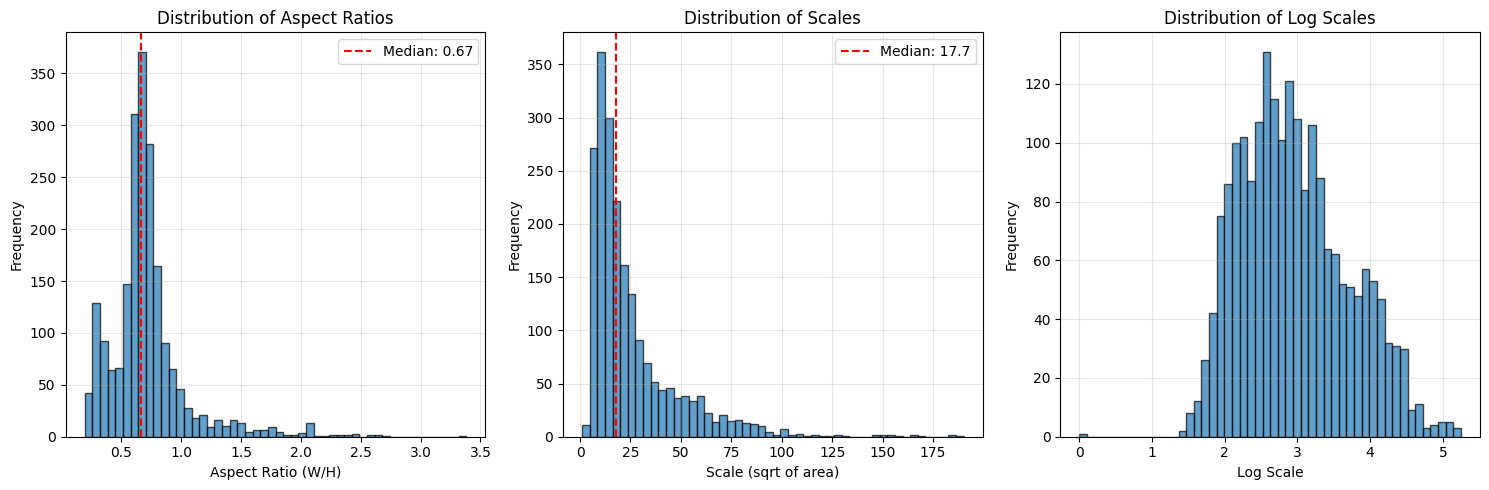

📊 데이터셋 통계
총 annotation 수: 2069
평균 크기: 25.8
중앙값 크기: 17.7
평균 비율: 0.71
중앙값 비율: 0.67

🎯 추천 Anchor Ratios
Percentile 기반 (20%, 50%, 80%):
  Simple format: [np.float64(0.52), np.float64(0.67), np.float64(0.82)]
  Tuple format: [(np.float64(0.52), 1.0), (np.float64(0.67), 1.0), (np.float64(0.82), 1.0)]

📏 추천 Anchor Scales
절대값: [np.float64(9.6), np.float64(17.7), np.float64(37.6)]
정규화 (중앙값 기준): [np.float64(0.54), np.float64(1.0), np.float64(2.13)]
기준 크기: 17.7

💡 실제 설정 예시
# EfficientDet/RetinaNet 스타일
anchor_ratios = [np.float64(0.52), np.float64(0.67), np.float64(0.82)]
anchor_scales = [np.float64(0.54), np.float64(1.0), np.float64(2.13)]

# 또는 전통적인 설정
anchor_ratios = [0.5, 1.0, 2.0]
anchor_scales = [1.0, 1.26, 1.587]  # 2^(0/3), 2^(1/3), 2^(2/3)

📋 주요 카테고리별 비율 분석
  Car: 0.71 (samples: 1527)
  Motorcycle: 0.31 (samples: 281)
  Pickup: 0.56 (samples: 190)
  Truck: 1.45 (samples: 47)
  Bus: 0.36 (samples: 24)


{'ratios_simple': [np.float64(0.52), np.float64(0.67), np.float64(0.82)],
 'ratios_tuple': [(np.float64(0.52), 1.0),
  (np.float64(0.67), 1.0),
  (np.float64(0.82), 1.0)],
 'scales_normalized': [np.float64(0.54), np.float64(1.0), np.float64(2.13)],
 'scales_absolute': [np.float64(9.6), np.float64(17.7), np.float64(37.6)],
 'base_scale': np.float64(17.663521732655695),
 'stats': {'total_annotations': 2069,
  'mean_ratio': np.float64(0.7142181132304681),
  'median_ratio': np.float64(0.6666666666666666),
  'mean_scale': np.float64(25.800453307673692),
  'median_scale': np.float64(17.663521732655695)}}

In [65]:
analyze_bbox_ratios_and_scales('./datasets/car_detect/No_Apply_Grayscale/No_Apply_Grayscale/Vehicles_Detection.v8i.coco/train/_annotations.coco.json')

In [71]:
import json
c = json.load(open(f'{SRC}/train/_annotations.coco.json'))
print(c['images'][0]['width'], 'x', c['images'][0]['height'])

640 x 640


In [66]:
import json

def extract_obj_list(coco_json_path):
    with open(coco_json_path, 'r') as f:
        coco = json.load(f)

    obj_list = [cat['name'] for cat in sorted(coco['categories'], key=lambda x: x['id'])]
    print("obj_list:", obj_list)
    return obj_list


In [67]:
extract_obj_list('./datasets/car_detect/No_Apply_Grayscale/No_Apply_Grayscale/Vehicles_Detection.v8i.coco/train/_annotations.coco.json')

obj_list: ['cars', 'Bus', 'Car', 'Motorcycle', 'Pickup', 'Truck']


['cars', 'Bus', 'Car', 'Motorcycle', 'Pickup', 'Truck']

변환 후 최종 디렉토리 구조
*Final directory layout after conversion*

- Yet-Another-EfficientDet-Pytorch
    - projects
        - my_car_detect_proj.yml
    - datasets
        - car_detect
        - my_car_detect
            - annotations
                - instances_train.json
                - instances_valid.json
                - instances_test.json
            - train
                - XXX.jpg
                - XXX.jpg
            - valid
                - XXX.jpg
                - XXX.jpg
            - test
                - XXX.jpg
                - XXX.jpg

In [68]:
import os
import shutil
import json
from pathlib import Path

# 1) 설정: 원본/대상 경로 및 split 정의
SRC_ROOT = Path("datasets/car_detect/No_Apply_Grayscale/No_Apply_Grayscale/Vehicles_Detection.v8i.coco")
DST_ROOT = Path("datasets/my_car_detect_proj")
ANNOT_DIR = DST_ROOT / "annotations"
SPLITS = ["train", "valid", "test"]

# 2) 대상 디렉토리 생성
for p in [DST_ROOT, ANNOT_DIR] + [DST_ROOT / s for s in SPLITS]:
    p.mkdir(parents=True, exist_ok=True)

# 3) split별 이미지 복사 및 annotation 변환·저장
for split in SPLITS:
    src_split = SRC_ROOT / split
    dst_split = DST_ROOT / split
    dst_split.mkdir(exist_ok=True)

    # 3-1) 이미지 파일(.jpg/.png) 복사
    for ext in ("*.jpg", "*.png"):
        for img_path in src_split.glob(ext):
            shutil.copy(img_path, dst_split / img_path.name)

    # 3-2) annotation JSON 변환
    #    - 원본 JSON 불러오기
    #    - COCO to EfficientDet-PyTorch 형식 변환
    #    - instances_{split}.json으로 저장
    for json_path in src_split.glob("*.json"):
        with open(json_path, "r", encoding="utf-8") as f:
            before = json.load(f)

        # 새 구조 준비
        tobe = {
            "images": [],
            "type": "instances",
            "annotations": [],
            "categories": []
        }

        # images 필드
        for img in before.get("images", []):
            tobe["images"].append({
                "file_name": img["file_name"],
                "height": img["height"],
                "width": img["width"],
                "id": img["id"]
            })

        # annotations 필드
        for ann in before.get("annotations", []):
            tobe["annotations"].append({
                "id": ann["id"],
                "image_id": ann["image_id"],
                "category_id": ann["category_id"],
                "bbox": ann["bbox"],
                "area": ann["area"],
                "iscrowd": ann.get("iscrowd", 0),
                "ignore": 0,
                "segmentation": ann.get("segmentation", [])
            })

        # categories 필드
        for cat in before.get("categories", []):
            tobe["categories"].append({
                "supercategory": cat.get("supercategory", ""),
                "id": cat["id"],
                "name": cat["name"]
            })

        # 저장
        dst_json = ANNOT_DIR / f"instances_{split}.json"
        with open(dst_json, "w", encoding="utf-8") as f:
            json.dump(tobe, f, ensure_ascii=False, indent=2)

        print(f"[{split}] {json_path.name} → {dst_json.name}")

print("✅ 전체 폴더 구조 및 annotation 변환 완료!")


[train] _annotations.coco.json → instances_train.json
[valid] _annotations.coco.json → instances_valid.json
[test] _annotations.coco.json → instances_test.json
✅ 전체 폴더 구조 및 annotation 변환 완료!


In [69]:
!ls datasets/my_car_detect_proj/annotations/
!ls datasets/my_car_detect_proj/train | wc -l

instances_test.json  instances_train.json  instances_valid.json
102


In [70]:
import os
import shutil
from pathlib import Path

# 원본 루트 (변경 필요 시 수정)
SRC_ROOT = Path("datasets/car_detect/Apply_Grayscale/Apply_Grayscale/Vehicles_Detection.v9i.coco")

# 대상 루트
DST_ROOT = Path("datasets/my_car_detect_proj")
ANNOT_DIR = DST_ROOT / "annotations"

# splits 정보
SPLITS = ["train", "valid", "test"]

# annotation 파일 패턴 (원본 디렉토리 안에서 *.json 찾기)
ANNOT_PATTERN = "_annotations.coco.json"  # test에만 있다면 'test'만 복사됩니다.

# 1) 대상 디렉토리 생성
for d in [DST_ROOT, ANNOT_DIR] + [DST_ROOT / s for s in SPLITS]:
    d.mkdir(parents=True, exist_ok=True)

# 2) 이미지 파일 복사 및 annotation 파일 복사
for split in SPLITS:
    src_split = SRC_ROOT / split
    dst_split = DST_ROOT / split

    # 이미지(.jpg/.png) 복사
    for ext in ("*.jpg", "*.png"):
        for img_path in src_split.glob(ext):
            shutil.copy(img_path, dst_split / img_path.name)

    # annotation JSON 복사 (split별로 이름 바꿔 복사)
    # 만약 train/valid 폴더에도 JSON이 있다면 동일 로직으로 처리됩니다.
    for json_path in src_split.glob("*.json"):
        dst_json = ANNOT_DIR / f"instances_{split}.json"
        shutil.copy(json_path, dst_json)
        print(f"Copied annotation for {split}: {json_path.name} → {dst_json.name}")

print("✅ 폴더 구조 변환 완료!")

Copied annotation for train: _annotations.coco.json → instances_train.json
Copied annotation for valid: _annotations.coco.json → instances_valid.json
Copied annotation for test: _annotations.coco.json → instances_test.json
✅ 폴더 구조 변환 완료!


In [72]:
yml = """project_name: my_car_detect_proj
train_set: train
val_set: valid
num_gpus: 1

mean: [0.4639, 0.4724, 0.4700]
std: [0.1653, 0.1642, 0.1631]

anchors_scales: '[0.25, 0.5, 1.0]'
anchors_ratios: '[(0.7, 1.4), (1.0, 1.0), (1.4, 0.7)]'

obj_list: ['Bus', 'Car', 'Motorcycle', 'Pickup', 'Truck']
"""
with open('projects/my_car_detect_proj.yml', 'w') as f:
    f.write(yml)

!cat projects/my_car_detect_proj.yml

project_name: my_car_detect_proj
train_set: train
val_set: valid
num_gpus: 1

mean: [0.4639, 0.4724, 0.4700]
std: [0.1653, 0.1642, 0.1631]

anchors_scales: '[0.25, 0.5, 1.0]'
anchors_ratios: '[(0.7, 1.4), (1.0, 1.0), (1.4, 0.7)]'

obj_list: ['Bus', 'Car', 'Motorcycle', 'Pickup', 'Truck']


```python

project_name: car_detect_proj  # also the folder name of the dataset that under data_path folder
train_set: train
val_set: valid
num_gpus: 0

# mean and std in RGB order, actually this part should remain unchanged as long as your dataset is similar to coco.
mean: [0.4639068720376132, 0.4723598790503507, 0.4700067273366889]
std: [0.16533415666407805, 0.16423948194385204, 0.16310458962308103]

# this is coco anchors, change it if necessary
anchors_scales: '[0.54, 1.0, 2.13]'
anchors_ratios: '[(0.52, 1.0), (0.67, 1.0), (0.82, 1.0)]'

# must match your dataset's category_id.
# category_id is one_indexed,
# for example, index of 'car' here is 2, while category_id of is 3
obj_list: ['cars', 'Bus', 'Car', 'Motorcycle', 'Pickup', 'Truck']

```

In [73]:
import yaml
print(yaml.safe_load(open('projects/my_car_detect_proj.yml')))

{'project_name': 'my_car_detect_proj', 'train_set': 'train', 'val_set': 'valid', 'num_gpus': 1, 'mean': [0.4639, 0.4724, 0.47], 'std': [0.1653, 0.1642, 0.1631], 'anchors_scales': '[0.25, 0.5, 1.0]', 'anchors_ratios': '[(0.7, 1.4), (1.0, 1.0), (1.4, 0.7)]', 'obj_list': ['Bus', 'Car', 'Motorcycle', 'Pickup', 'Truck']}


## 3. 학습 (Custom dataset)
*3. Training on the custom dataset*

사전학습 가중치(COCO, d0)에서 출발해 **4단계**로 나누어 학습했다.
각 단계는 직전 단계의 마지막 체크포인트를 이어받는다
(`--num_epochs`는 "이번 단계 epoch 수"가 아니라 **누적 목표 epoch**).

*Starting from the COCO-pretrained d0 weights, training was split into **four stages**.
Each stage resumes from the previous stage's last checkpoint
(`--num_epochs` is the **cumulative target epoch**, not the number of epochs for that run).*

| 단계 / Stage | 학습 범위 / Trainable part | lr | epoch (누적 / cumulative) | 최종 val loss / Final val loss | test mAP@[.5:.95] |
|---|---|---|---|---|---|
| 1 | head만 / head only (`--head_only True`) | 1e-3 | 0 → 10 | 35.938 | – |
| 2 | 전체 / full model (`--head_only False`) | 1e-3 | 10 → 30 | 1.889 | 0.104 |
| 3 | 전체 / full model | 1e-4 | 30 → 40 | 1.674 | – |
| 4 | 전체 / full model | 1e-4 | 40 → 80 | 1.566 | **0.280** |

- 1단계는 head가 5-class로 새로 초기화되므로 cls loss가 매우 크다. head만 먼저 안정화시키는 워밍업 단계.
- 2단계에서 backbone까지 풀자 loss가 급감(35.9 → 1.89)했다.
- 3~4단계는 lr을 1/10로 낮춰 미세 조정. epoch을 80까지 늘리며 mAP가 0.104 → 0.280으로 올랐다.

*- Stage 1 starts with a freshly initialised 5-class head, so the classification loss is huge.
  It is a warm-up that stabilises the head alone.
- Unfreezing the backbone in stage 2 dropped the loss sharply (35.9 → 1.89).
- Stages 3–4 fine-tune at 1/10 the learning rate. Extending training to 80 epochs raised mAP from 0.104 to 0.280.*

### 3-1. 학습 준비
*3-1. Training setup*

`train.py`의 스케줄러 한 줄을 수정한다 (최신 PyTorch에서 `verbose` 인자가 제거되어 에러가 난다)
*Patch one scheduler line in `train.py` — newer PyTorch removed the `verbose` argument, which raises an error*

- scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, verbose=True)
- 에러 발생 시 => 아래와 같이 수정 / if it errors => change it to:
- scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)

In [74]:
!pip install tensorboardX

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 3.2 MB/s eta 0:00:00


In [75]:
!sed -i 's/patience=3, verbose=True/patience=3/' train.py
!grep -n "ReduceLROnPlateau" train.py

193:    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)


In [76]:
!pwd

/content/Yet-Another-EfficientDet-Pytorch


### 3-2. 1단계 — head only, lr 1e-3, ~10 epoch
*3-2. Stage 1 — head only, lr 1e-3, up to epoch 10*

새로 붙인 5-class head만 학습시켜 워밍업한다.
backbone은 COCO 가중치 그대로 고정(`--head_only True`).

*Warm up by training only the newly attached 5-class head.
The backbone stays frozen at its COCO weights (`--head_only True`).*

In [77]:
! python train.py -c 0 -p my_car_detect_proj --head_only True --lr 1e-3 --batch_size 16 --load_weights weights/efficientdet-d0.pth --num_epochs 10 --save_interval 100 --num_workers 2

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[Warning] Ignoring Error(s) in loading state_dict for EfficientDetBackbone:
	size mismatch for classifier.header.pointwise_conv.conv.weight: copying a param with shape torch.Size([810, 64, 1, 1]) from checkpoint, the shape in current model is torch.Size([45, 64, 1, 1]).
	size mismatch for classifier.header.pointwise_conv.conv.bias: copying a param with shape torch.Size([810]) from checkpoint, the shape in current model is torch.Size([45]).
[Warning] Don't panic if you see this, this might be because you load a pretrained weights with different number of classes. The rest of the weights should be loaded already.
[Info] loaded weights: efficientdet-d0.pth, resuming checkpoint from step: 0
[Info] freezed backbone
  0% 0/8 [00:00<?, ?it/s]/content/Yet-Another-EfficientDet-Pytorch/train.py:238: UserWarning: Converting a tensor 

In [78]:
!ls -l logs/my_car_detect_proj/


total 154404
-rw-r--r-- 1 root root 15807271 Sep 28 05:31 efficientdet-d0_0_8.pth
-rw-r--r-- 1 root root 15808061 Sep 28 05:31 efficientdet-d0_1_16.pth
-rw-r--r-- 1 root root 15808061 Sep 28 05:31 efficientdet-d0_2_24.pth
-rw-r--r-- 1 root root 15808061 Sep 28 05:31 efficientdet-d0_3_32.pth
-rw-r--r-- 1 root root 15808061 Sep 28 05:31 efficientdet-d0_4_40.pth
-rw-r--r-- 1 root root 15808061 Sep 28 05:31 efficientdet-d0_5_48.pth
-rw-r--r-- 1 root root 15808061 Sep 28 05:31 efficientdet-d0_6_56.pth
-rw-r--r-- 1 root root 15808061 Sep 28 05:31 efficientdet-d0_7_64.pth
-rw-r--r-- 1 root root 15808061 Sep 28 05:32 efficientdet-d0_8_72.pth
-rw-r--r-- 1 root root 15808061 Sep 28 05:32 efficientdet-d0_9_80.pth
drwxr-xr-x 3 root root     4096 Sep 28 05:31 tensorboard


### 3-3. 2단계 — 전체 학습, lr 1e-3, 10 → 30 epoch
*3-3. Stage 2 — full model, lr 1e-3, epoch 10 → 30*

1단계 마지막 체크포인트(`efficientdet-d0_9_80.pth`)를 불러와
backbone까지 포함해 전체를 학습한다(`--head_only False`).

*Load stage 1's last checkpoint (`efficientdet-d0_9_80.pth`) and train the whole
model, backbone included (`--head_only False`).*

In [79]:
! python train.py -c 0 -p my_car_detect_proj --head_only False --lr 1e-3 --batch_size 16 --load_weights './logs/my_car_detect_proj/efficientdet-d0_9_80.pth' --num_epochs 30 --save_interval 100 --num_workers 2

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[Info] loaded weights: efficientdet-d0_9_80.pth, resuming checkpoint from step: 80
  0% 0/8 [00:00<?, ?it/s]/content/Yet-Another-EfficientDet-Pytorch/train.py:238: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  epoch_loss.append(float(loss))
Step: 87. Epoch: 10/30. Iteration: 8/8. Cls loss: 3.08256. Reg loss: 2.59271. Total loss: 5.67528: 100% 8/8 [00:22<00:00,  2.82s/it]
Val. Epoch: 10/30. Classification loss: 2.99902. Regression loss: 3.44359. Total loss: 6.44261
Step: 95. Epoch: 11/30. Iteration: 8/8. Cls loss: 1.34018. Reg loss: 2.05046. Total loss: 3.39064: 100% 8/8 [00:09<00:00,  1.24s/it]
Val. Epoch: 11/30. Classification loss

In [80]:
!ls -lt logs/my_car_detect_proj/ | head -20

total 447764
-rw-r--r-- 1 root root 15809897 Sep 28 05:40 efficientdet-d0_29_240.pth
-rw-r--r-- 1 root root 15809897 Sep 28 05:39 efficientdet-d0_28_232.pth
-rw-r--r-- 1 root root 15809897 Sep 28 05:39 efficientdet-d0_27_224.pth
-rw-r--r-- 1 root root 15809897 Sep 28 05:39 efficientdet-d0_26_216.pth
-rw-r--r-- 1 root root 15809897 Sep 28 05:39 efficientdet-d0_24_200.pth
-rw-r--r-- 1 root root 15809897 Sep 28 05:38 efficientdet-d0_23_192.pth
-rw-r--r-- 1 root root 15809897 Sep 28 05:38 efficientdet-d0_22_184.pth
-rw-r--r-- 1 root root 15809897 Sep 28 05:38 efficientdet-d0_20_168.pth
-rw-r--r-- 1 root root 15809897 Sep 28 05:38 efficientdet-d0_19_160.pth
-rw-r--r-- 1 root root 15809897 Sep 28 05:37 efficientdet-d0_18_152.pth
-rw-r--r-- 1 root root 15809897 Sep 28 05:37 efficientdet-d0_17_144.pth
-rw-r--r-- 1 root root 15809897 Sep 28 05:37 efficientdet-d0_16_136.pth
-rw-r--r-- 1 root root 15809897 Sep 28 05:37 efficientdet-d0_15_128.pth
-rw-r--r-- 1 root root 15809897 Sep 28 05:37 effici

In [81]:
import glob, os
weight_path = sorted(glob.glob('logs/my_car_detect_proj/*.pth'), key=os.path.getmtime)[-1]
print(weight_path)

logs/my_car_detect_proj/efficientdet-d0_29_240.pth


#### 2단계 결과 평가 (test set COCO eval)
*Stage 2 evaluation — COCO eval on the test set*

In [82]:
!python coco_eval.py -c 0 -p my_car_detect_proj -w "{weight_path}"

running coco-style evaluation on project my_car_detect_proj, weights logs/my_car_detect_proj/efficientdet-d0_29_240.pth...
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
100% 28/28 [00:08<00:00,  3.31it/s]
Loading and preparing results...
DONE (t=0.68s)
creating index...
index created!
BBox
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=2.36s).
Accumulating evaluation results...
DONE (t=0.22s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.104
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.183
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.091
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.045
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.218
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.361
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | max

### 3-4. 3단계 — 전체 학습, lr 1e-4, 30 → 40 epoch
*3-4. Stage 3 — full model, lr 1e-4, epoch 30 → 40*

2단계에서 loss가 정체되어 **lr을 1e-3 → 1e-4로 낮춰** 미세 조정한다.
설정 중 바뀐 것은 lr과 목표 epoch뿐이다.

*The loss plateaued in stage 2, so fine-tune with the **learning rate lowered from 1e-3 to 1e-4**.
Only the lr and the target epoch differ from the previous stage.*

In [91]:
!python train.py -c 0 -p my_car_detect_proj --head_only False --lr 1e-4 --batch_size 16 --load_weights "{weight_path}" --num_epochs 40 --save_interval 100 --num_workers 2

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[Info] loaded weights: efficientdet-d0_29_240.pth, resuming checkpoint from step: 240
  0% 0/8 [00:00<?, ?it/s]/content/Yet-Another-EfficientDet-Pytorch/train.py:238: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  epoch_loss.append(float(loss))
Step: 247. Epoch: 30/40. Iteration: 8/8. Cls loss: 0.36558. Reg loss: 0.57273. Total loss: 0.93831: 100% 8/8 [00:22<00:00,  2.85s/it]
Val. Epoch: 30/40. Classification loss: 0.43285. Regression loss: 1.43843. Total loss: 1.87128
Step: 255. Epoch: 31/40. Iteration: 8/8. Cls loss: 0.29864. Reg loss: 0.51768. Total loss: 0.81632: 100% 8/8 [00:10<00:00,  1.31s/it]
Val. Epoch: 31/40. Classification

### 3-5. 4단계 — 전체 학습, lr 1e-4, 40 → 80 epoch
*3-5. Stage 4 — full model, lr 1e-4, epoch 40 → 80*

lr은 3단계와 같고 **학습을 80 epoch까지 연장**한 것만 다르다.

*Same lr as stage 3; the only change is **extending training out to 80 epochs**.*

In [ ]:
# 다음 단계에 이어붙일 최신 체크포인트 갱신
import glob, os
weight_path = sorted(glob.glob('logs/my_car_detect_proj/*.pth'), key=os.path.getmtime)[-1]
print(weight_path)

In [93]:
!python train.py -c 0 -p my_car_detect_proj --head_only False --lr 1e-4 --batch_size 16 --load_weights "{weight_path}" --num_epochs 80 --save_interval 100 --num_workers 2

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[Info] loaded weights: efficientdet-d0_39_320.pth, resuming checkpoint from step: 320
  0% 0/8 [00:00<?, ?it/s]/content/Yet-Another-EfficientDet-Pytorch/train.py:238: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  epoch_loss.append(float(loss))
Step: 327. Epoch: 40/80. Iteration: 8/8. Cls loss: 0.23510. Reg loss: 0.32561. Total loss: 0.56071: 100% 8/8 [00:23<00:00,  2.88s/it]
Val. Epoch: 40/80. Classification loss: 0.33935. Regression loss: 1.31157. Total loss: 1.65092
Step: 335. Epoch: 41/80. Iteration: 8/8. Cls loss: 0.25121. Reg loss: 0.58728. Total loss: 0.83850: 100% 8/8 [00:10<00:00,  1.26s/it]
Val. Epoch: 41/80. Classification

#### 4단계 결과 평가 — 최종 모델
*Stage 4 evaluation — final model*

In [94]:
import glob, os
weight_path = sorted(glob.glob('logs/my_car_detect_proj/*.pth'), key=os.path.getmtime)[-1]
print(weight_path)
!python coco_eval.py -c 0 -p my_car_detect_proj -w "{weight_path}"

logs/my_car_detect_proj/efficientdet-d0_76_616.pth
running coco-style evaluation on project my_car_detect_proj, weights logs/my_car_detect_proj/efficientdet-d0_76_616.pth...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
100% 28/28 [00:09<00:00,  2.90it/s]
Loading and preparing results...
DONE (t=0.04s)
creating index...
index created!
BBox
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.90s).
Accumulating evaluation results...
DONE (t=0.07s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.280
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.464
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.285
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.196
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.438
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.464
 Average R

### 3-6. 학습한 모델로 추론
*3-6. Inference with the trained model*

학습에 쓴 것과 **같은 anchor 설정**(`ratios`, `scales`)과 `num_classes=5`로
모델을 만들어야 체크포인트가 그대로 로드된다.
`iou_threshold`는 0.2 → 0.1로 낮춰 중복 박스를 줄였다.

*The model must be built with the **same anchor settings** (`ratios`, `scales`) and
`num_classes=5` used during training, otherwise the checkpoint will not load cleanly.
`iou_threshold` was lowered from 0.2 to 0.1 to suppress duplicate boxes.*

class_ids: [1 4 3]
scores   : [0.65  0.578 0.384]
3 detections


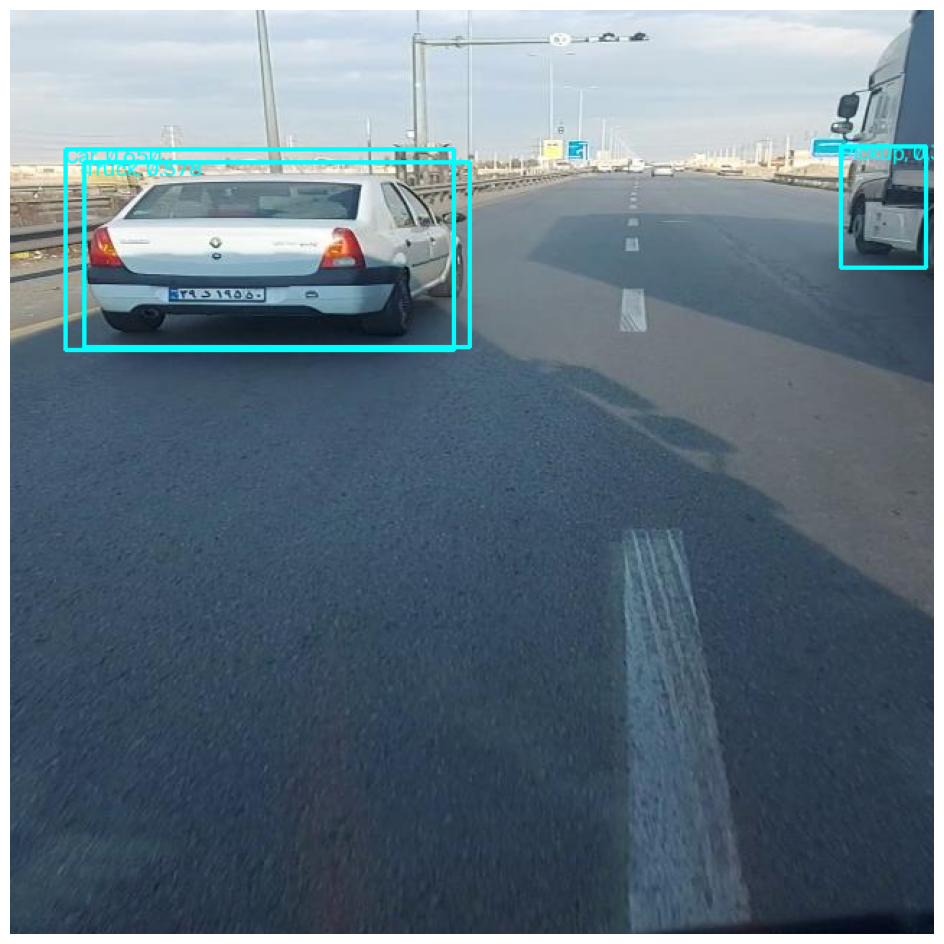

In [95]:
import torch
from torch.backends import cudnn

from backbone import EfficientDetBackbone
import cv2
import matplotlib.pyplot as plt
import numpy as np

from efficientdet.utils import BBoxTransform, ClipBoxes
from utils.utils import preprocess, invert_affine, postprocess

compound_coef = 0
force_input_size = None  # set None to use default size

threshold = 0.3
iou_threshold = 0.1     # was 0.2 — higher suppresses duplicate boxes

use_cuda = True
use_float16 = False

# the head was trained with 5 classes — this must stay 5
num_classes = 5
# display lookup only — shifted by one to test the category_id offset
obj_list = ['Bus', 'Car', 'Motorcycle', 'Pickup', 'Truck']

input_sizes = [512, 640, 768, 896, 1024, 1280, 1280, 1536]
input_size = input_sizes[compound_coef] if force_input_size is None else force_input_size
ori_imgs, framed_imgs, framed_metas = preprocess(img_path, max_size=input_size)

if use_cuda:
    x = torch.stack([torch.from_numpy(fi).cuda() for fi in framed_imgs], 0)
else:
    x = torch.stack([torch.from_numpy(fi) for fi in framed_imgs], 0)

x = x.to(torch.float32 if not use_float16 else torch.float16).permute(0, 3, 1, 2)

model = EfficientDetBackbone(compound_coef=compound_coef, num_classes=num_classes,
                             ratios=[(0.7, 1.4), (1.0, 1.0), (1.4, 0.7)],
                             scales=[0.25, 0.5, 1.0])

model.load_state_dict(torch.load(weight_path))
model.requires_grad_(False)
model.eval()

if use_cuda:
    model = model.cuda()
if use_float16:
    model = model.half()

with torch.no_grad():
    features, regression, classification, anchors = model(x)

    regressBoxes = BBoxTransform()
    clipBoxes = ClipBoxes()

    out = postprocess(x,
                      anchors, regression, classification,
                      regressBoxes, clipBoxes,
                      threshold, iou_threshold)

out = invert_affine(framed_metas, out)

print('class_ids:', out[0]['class_ids'])
print('scores   :', out[0]['scores'].round(3))

for i in range(len(ori_imgs)):
    if len(out[i]['rois']) == 0:
        print('no detections')
        continue
    ori_imgs[i] = ori_imgs[i].copy()
    for j in range(len(out[i]['rois'])):
        (x1, y1, x2, y2) = out[i]['rois'][j].astype(np.int32)
        cv2.rectangle(ori_imgs[i], (x1, y1), (x2, y2), (255, 255, 0), 2)
        obj = obj_list[out[i]['class_ids'][j]]
        score = float(out[i]['scores'][j])

        cv2.putText(ori_imgs[i], '{}, {:.3f}'.format(obj, score),
                    (x1, y1 + 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                    (255, 255, 0), 1)

    print(f'{len(out[i]["rois"])} detections')
    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(ori_imgs[i], cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

### 3-7. 정리
*3-7. Summary*

- **단계적 학습이 효과적이었다.** head만 먼저 워밍업(1단계) → 전체 해제(2단계) →
  lr 감소(3~4단계) 순으로 진행하며 val total loss가 35.94 → 1.57까지 내려갔다.
- **lr 감소보다 epoch 연장이 더 크게 기여했다.** 3단계(40 epoch)와 4단계(80 epoch)는
  lr이 동일한데, 학습을 연장한 쪽에서 mAP가 0.104 → 0.280으로 뚜렷하게 올랐다.
- **남은 한계:** 최종 mAP@[.5:.95] 0.280, small object AP는 0.196으로 여전히 낮다.
  데이터셋 통계로 재계산한 anchor scale(`[0.25, 0.5, 1.0]`)을 썼는데도 작은 차량 검출이 약하므로,
  입력 해상도를 키우거나(d1~d2) 학습 데이터를 늘리는 쪽을 다음 개선안으로 본다.

*- **Staged training paid off.** Warming up the head (stage 1) → unfreezing everything (stage 2) →
  dropping the lr (stages 3–4) brought the validation total loss down from 35.94 to 1.57.
- **Longer training mattered more than the lr drop.** Stages 3 (40 epochs) and 4 (80 epochs) share the
  same lr, yet mAP rose clearly, 0.104 → 0.280, on the longer run.
- **Remaining limits:** final mAP@[.5:.95] is 0.280 and small-object AP is still only 0.196.
  Small vehicles are detected poorly even with anchor scales recomputed from the dataset
  (`[0.25, 0.5, 1.0]`), so the next things to try are a larger input resolution (d1-d2) or more training data.*